<a href="https://colab.research.google.com/github/Maryam-71295/Hex-Softwares_School-Performance/blob/main/HexSoftwares_SchoolPerformance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots

pio.renderers.default = "notebook"

In [2]:
df = pd.read_csv("/content/StudentsPerformance.csv")

In [3]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


2) Data Overview & Preprocessing

In [4]:
df.shape

(1000, 8)

In [5]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [6]:
df.isnull().sum()

,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


In [17]:
df.duplicated().sum()

np.int64(0)

In [7]:
df["average score"] = df[["math score", "writing score", "reading score"]].mean(axis=1).round(2)

In [8]:
def grade(average_score):
    if average_score < 40:
        return "F"
    elif 40<= average_score < 60:
        return "D"
    elif 60<= average_score < 75:
        return "C"
    elif 75<= average_score < 90:
        return "B"
    else:
        return "A"

In [9]:
df["grade"] = df["average score"].apply(grade)

In [10]:
df.describe()

,math score,reading score,writing score,average score
count,1000.00000,1000.000000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000,67.770580
std,15.16308,14.600192,15.195657,14.257311
min,0.00000,17.000000,10.000000,9.000000
25%,57.00000,59.000000,57.750000,58.330000
50%,66.00000,70.000000,69.000000,68.330000
75%,77.00000,79.000000,79.000000,77.670000
max,100.00000,100.000000,100.000000,100.000000


Feature Engineering

In [18]:
SCORE_COLS = ["math score", "reading score", "writing score"]

In [19]:
#  Aggregate scores
df["total score"]   = df[SCORE_COLS].sum(axis=1)
df["average score"] = df[SCORE_COLS].mean(axis=1).round(2)
df["min score"]     = df[SCORE_COLS].min(axis=1)
df["max score"]     = df[SCORE_COLS].max(axis=1)

In [20]:
# Score range
df["score range"] = df["max score"] - df["min score"]

#Score standard deviation
df["score std"] = df[SCORE_COLS].std(axis=1).round(2)

In [21]:
# Verbal score (reading + writing average) vs. Quantitative (math)
df["verbal score"]       = df[["reading score", "writing score"]].mean(axis=1).round(2)
df["quant score"]        = df["math score"]

In [22]:
df["verbal quant gap"]   = (df["verbal score"] - df["quant score"]).round(2)

In [23]:
df["strongest subject"]  = df[SCORE_COLS].idxmax(axis=1).str.replace(" score", "")
df["weakest subject"]    = df[SCORE_COLS].idxmin(axis=1).str.replace(" score", "")

In [24]:
# Z-scores per subject (performance relative to class)
from scipy import stats
for col in SCORE_COLS:
    df[f"z_{col.split()[0]}"] = stats.zscore(df[col]).round(3)

In [25]:
#  Percentile rank per subject
for col in SCORE_COLS:
    label = col.split()[0]
    df[f"pct_{label}"] = df[col].rank(pct=True).mul(100).round(1)

In [26]:
# Grade band (average score)
bins   = [0, 40, 55, 70, 85, 100]
labels = ["Failing", "Poor", "Average", "Good", "Excellent"]
df["grade band"] = pd.cut(df["average score"], bins=bins, labels=labels, right=True)

In [27]:
#  Pass / Fail flags
df["pass math"]    = (df["math score"]    >= 40).astype(int)
df["pass reading"] = (df["reading score"] >= 40).astype(int)
df["pass writing"] = (df["writing score"] >= 40).astype(int)
df["pass all"]     = (df[SCORE_COLS] >= 40).all(axis=1).astype(int)
df["num subjects passed"] = df[["pass math", "pass reading", "pass writing"]].sum(axis=1)

In [28]:
# High achiever / At-risk flags

df["high achiever"] = (df["average score"] >= 85).astype(int)
df["at risk"]       = (df["average score"] <  50).astype(int)

3) Exploratory Data Analysis

In [11]:
df.groupby("parental level of education").mean(numeric_only=True)

,math score,reading score,writing score,average score
parental level of education,,,,
associate's degree,67.882883,70.927928,69.896396,69.568964
bachelor's degree,69.389831,73.000000,73.381356,71.923983
high school,62.137755,64.704082,62.448980,63.097194
master's degree,69.745763,75.372881,75.677966,73.598644
some college,67.128319,69.460177,68.840708,68.476106
some high school,63.497207,66.938547,64.888268,65.107654


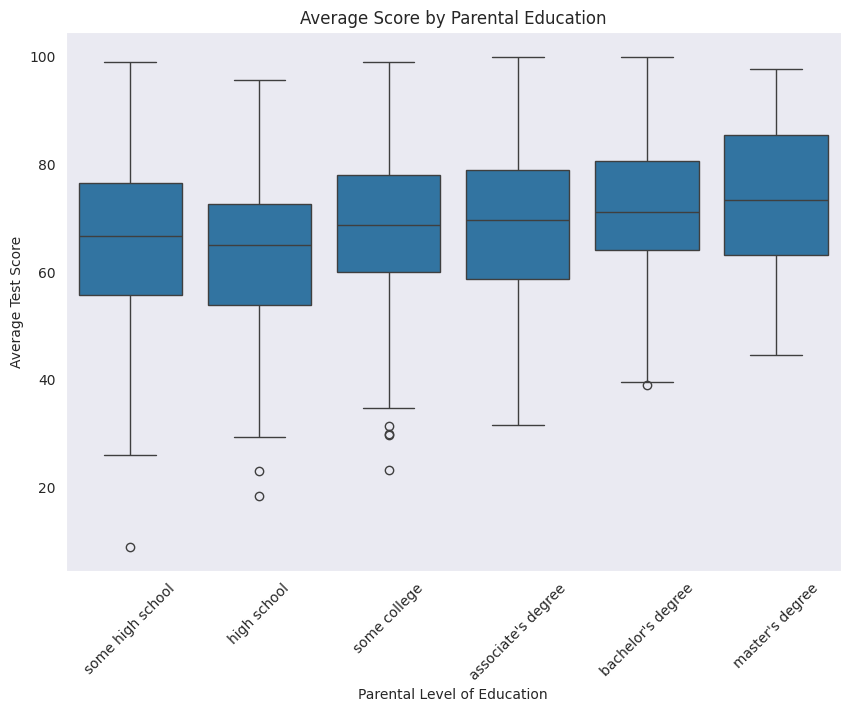

In [12]:
plt.figure(figsize=(10,7))
order = ['some high school', 'high school', 'some college', "associate's degree", "bachelor's degree", "master's degree"]
sns.set_style("dark")
sns.boxplot(x="parental level of education", y="average score", data=df, order=order)
plt.xlabel("Parental Level of Education")
plt.ylabel("Average Test Score")
plt.title("Average Score by Parental Education")
plt.xticks(rotation=45)
plt.show()

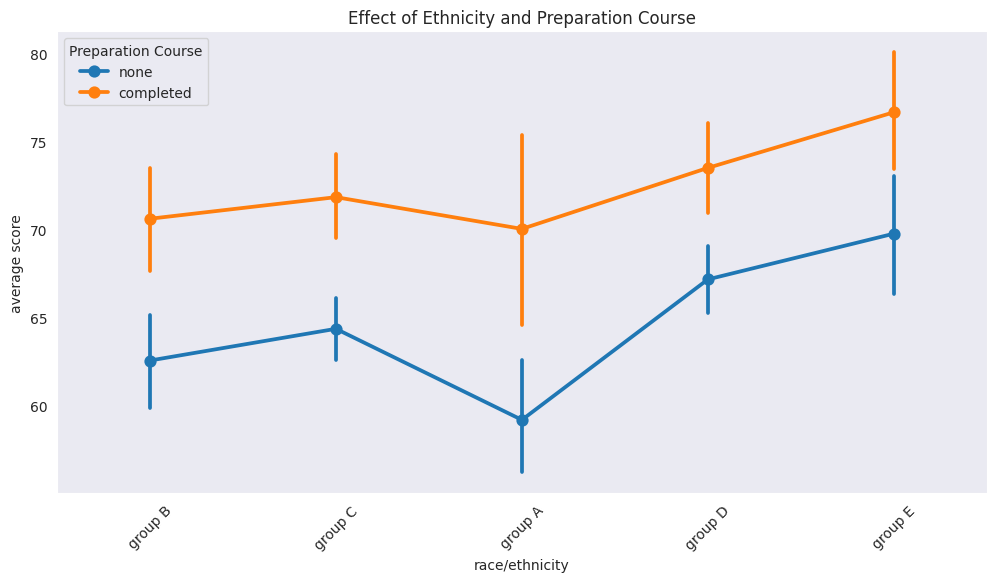

In [13]:
plt.figure(figsize=(12, 6))
sns.pointplot(x='race/ethnicity', y="average score", data=df, hue="test preparation course")
plt.xticks(rotation=45)
plt.legend(title="Preparation Course")
plt.title("Effect of Ethnicity and Preparation Course")
plt.show()

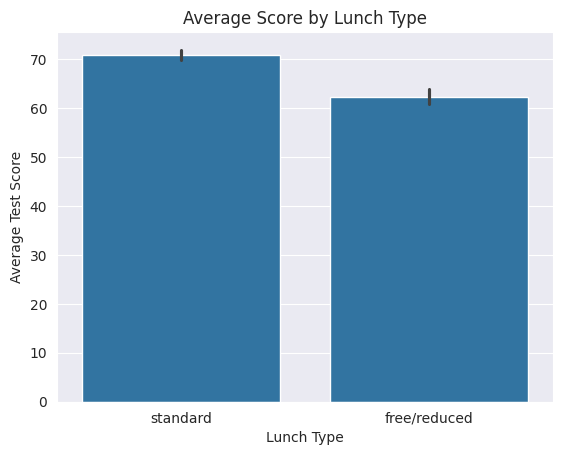

In [14]:
sns.set_style("darkgrid")
sns.barplot(x="lunch", y="average score", data=df)
plt.xlabel("Lunch Type")
plt.ylabel("Average Test Score")
plt.title("Average Score by Lunch Type")
plt.show()

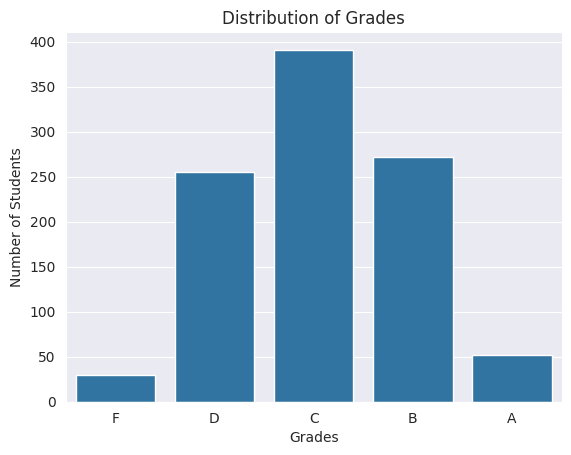

In [15]:
sns.set_style("darkgrid")
sns.countplot(x="grade", data=df, order=["F", "D", "C", "B", "A"])
plt.xlabel("Grades")
plt.ylabel("Number of Students")
plt.title("Distribution of Grades")
plt.show()

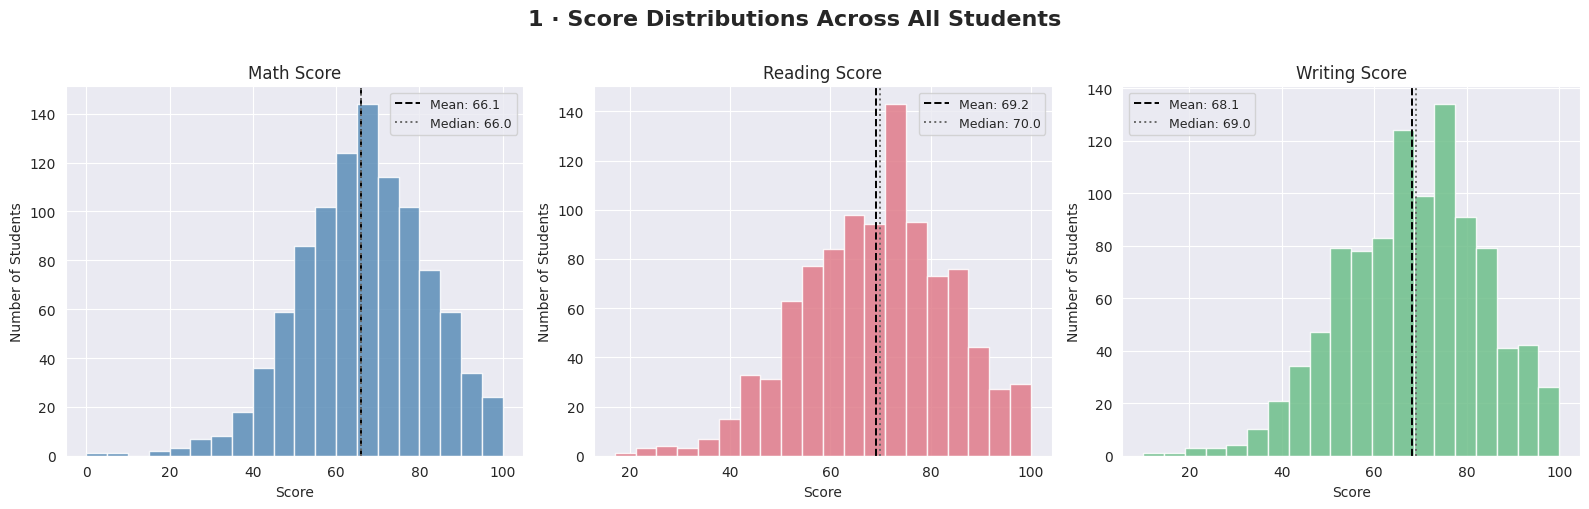

Descriptive Statistics:
       math score  reading score  writing score
count     1000.00        1000.00        1000.00
mean        66.09          69.17          68.05
std         15.16          14.60          15.20
min          0.00          17.00          10.00
25%         57.00          59.00          57.75
50%         66.00          70.00          69.00
75%         77.00          79.00          79.00
max        100.00         100.00         100.00


In [29]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("1 · Score Distributions Across All Students", fontsize=16, fontweight="bold", y=1.01)

colors = ["#5B8DB8", "#E07B8A", "#6DBF8A"]
for ax, col, color in zip(axes, SCORE_COLS, colors):
    data = df[col]
    ax.hist(data, bins=20, color=color, alpha=0.85, edgecolor="white")
    ax.axvline(data.mean(),  color="black",  linestyle="--", linewidth=1.4, label=f"Mean: {data.mean():.1f}")
    ax.axvline(data.median(),color="dimgray", linestyle=":",  linewidth=1.4, label=f"Median: {data.median():.1f}")
    ax.set_title(col.title())
    ax.set_xlabel("Score")
    ax.set_ylabel("Number of Students")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("01_score_distributions.png", bbox_inches="tight")
plt.show()
print("Descriptive Statistics:")
print(df[SCORE_COLS].describe().round(2))

/tmp/ipykernel_223/3460579244.py:6: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_223/3460579244.py:6: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_223/3460579244.py:6: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




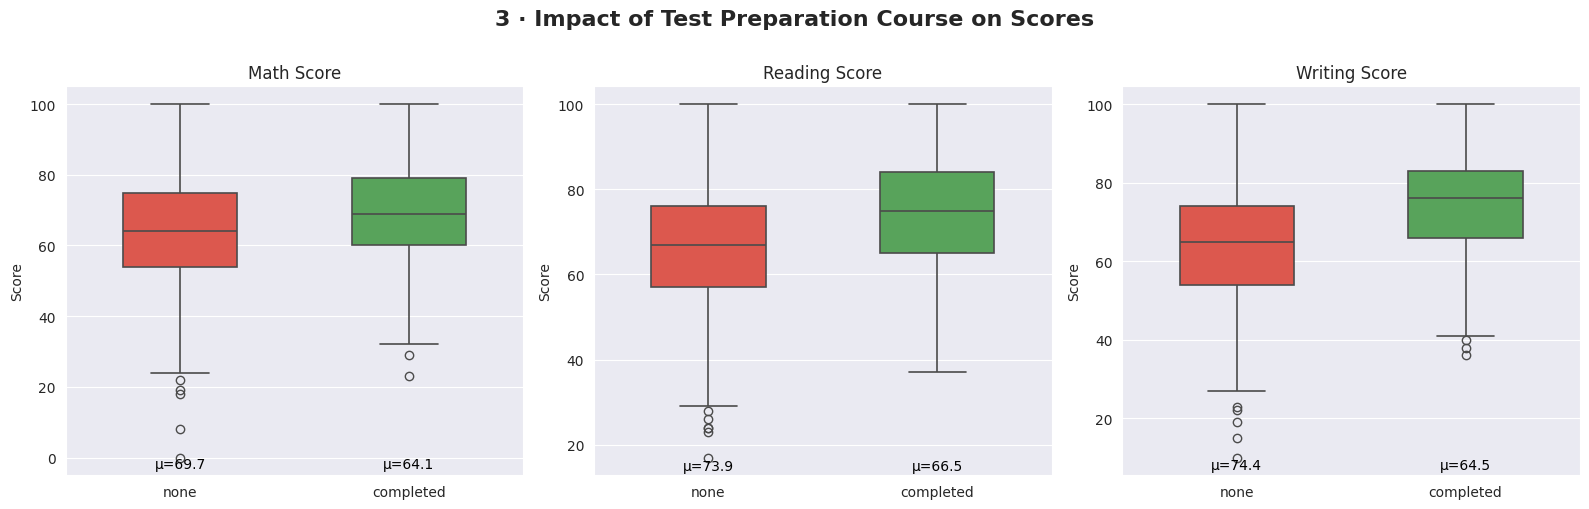


Mean scores by test preparation course:
                         math score  reading score  writing score
test preparation course                                          
completed                     69.70          73.89          74.42
none                          64.08          66.53          64.50

Score boost from completing prep course:
math score       5.62
reading score    7.36
writing score    9.92
dtype: float64


In [30]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("3 · Impact of Test Preparation Course on Scores", fontsize=16, fontweight="bold", y=1.01)

prep_palette = {"completed": "#4CAF50", "none": "#F44336"}
for ax, col in zip(axes, SCORE_COLS):
    sns.boxplot(data=df, x="test preparation course", y=col,
                palette=prep_palette, width=0.5, ax=ax, linewidth=1.2)
    for i, group in enumerate(["completed", "none"]):
        m = df[df["test preparation course"] == group][col].mean()
        ax.text(i, df[col].min() - 3, f"μ={m:.1f}", ha="center", fontsize=10, color="black")
    ax.set_title(col.title())
    ax.set_xlabel("")
    ax.set_ylabel("Score")

plt.tight_layout()
plt.savefig("03_test_prep_impact.png", bbox_inches="tight")
plt.show()

prep_means = df.groupby("test preparation course")[SCORE_COLS].mean().round(2)
print("\nMean scores by test preparation course:")
print(prep_means)
diff = prep_means.loc["completed"] - prep_means.loc["none"]
print("\nScore boost from completing prep course:")
print(diff.round(2))

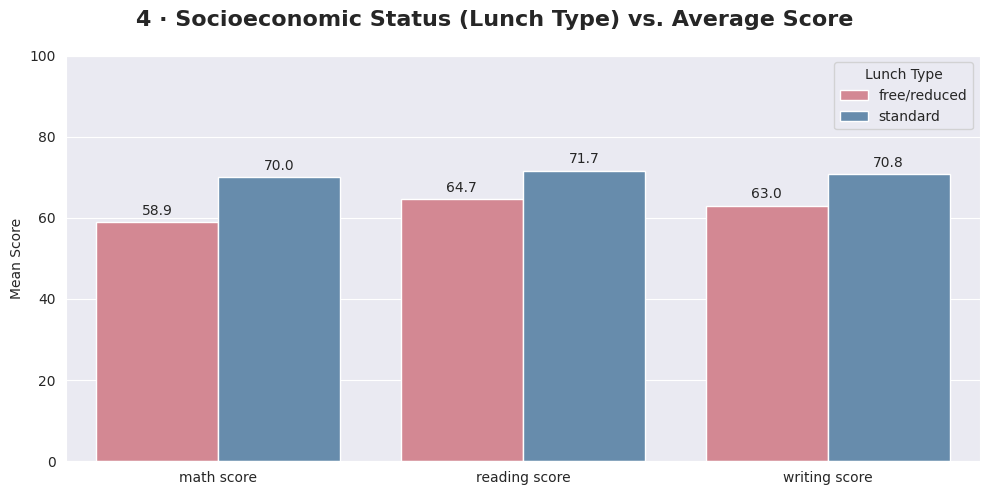


Mean scores by lunch type:
              math score  reading score  writing score  average score
lunch                                                                
free/reduced       58.92          64.65          63.02          62.20
standard           70.03          71.65          70.82          70.84


In [31]:
fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle("4 · Socioeconomic Status (Lunch Type) vs. Average Score",
             fontsize=16, fontweight="bold")

lunch_means = df.groupby("lunch")[SCORE_COLS].mean().reset_index()
lunch_long  = lunch_means.melt(id_vars="lunch", var_name="Subject", value_name="Mean Score")

sns.barplot(data=lunch_long, x="Subject", y="Mean Score", hue="lunch",
            palette={"standard": "#5B8DB8", "free/reduced": "#E07B8A"}, ax=ax)
ax.set_xlabel("")
ax.set_ylabel("Mean Score")
ax.set_ylim(0, 100)
ax.legend(title="Lunch Type")
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", padding=3, fontsize=10)

plt.tight_layout()
plt.savefig("04_lunch_type.png", bbox_inches="tight")
plt.show()

print("\nMean scores by lunch type:")
print(df.groupby("lunch")[SCORE_COLS + ["average score"]].mean().round(2))

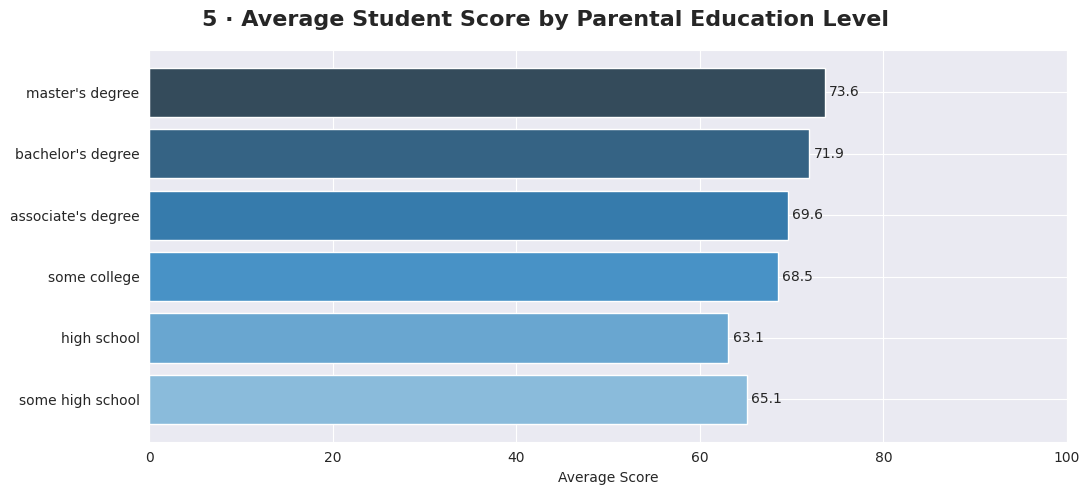


Average score by parental education:
                             average score
parental level of education               
some high school                     65.11
high school                          63.10
some college                         68.48
associate's degree                   69.57
bachelor's degree                    71.92
master's degree                      73.60


In [32]:
edu_order = [
    "some high school", "high school",
    "some college", "associate's degree",
    "bachelor's degree", "master's degree"
]
edu_means = df.groupby("parental level of education")["average score"].mean() \
              .reindex(edu_order).reset_index()

fig, ax = plt.subplots(figsize=(11, 5))
fig.suptitle("5 · Average Student Score by Parental Education Level",
             fontsize=16, fontweight="bold")

bars = ax.barh(edu_means["parental level of education"],
               edu_means["average score"],
               color=sns.color_palette("Blues_d", len(edu_means)))
ax.set_xlabel("Average Score")
ax.set_xlim(0, 100)
for bar, val in zip(bars, edu_means["average score"]):
    ax.text(val + 0.5, bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}", va="center", fontsize=10)

plt.tight_layout()
plt.savefig("05_parental_education.png", bbox_inches="tight")
plt.show()

print("\nAverage score by parental education:")
print(edu_means.set_index("parental level of education").round(2))

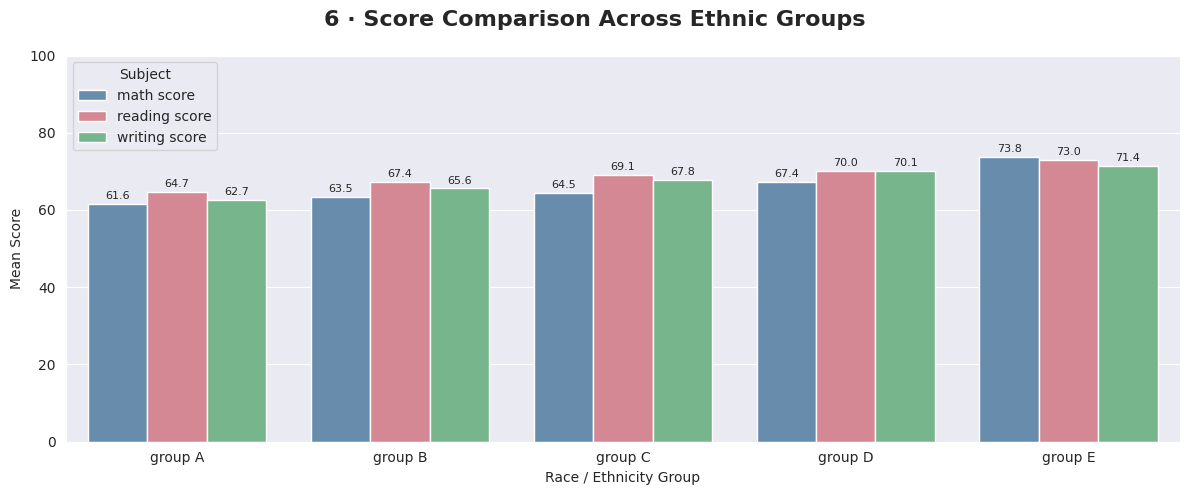


Mean scores by race/ethnicity:
                math score  reading score  writing score  average score
race/ethnicity                                                         
group A              61.63          64.67          62.67          62.99
group B              63.45          67.35          65.60          65.47
group C              64.46          69.10          67.83          67.13
group D              67.36          70.03          70.15          69.18
group E              73.82          73.03          71.41          72.75


In [33]:
race_means = df.groupby("race/ethnicity")[SCORE_COLS].mean().reset_index()
race_long  = race_means.melt(id_vars="race/ethnicity", var_name="Subject", value_name="Mean Score")

fig, ax = plt.subplots(figsize=(12, 5))
fig.suptitle("6 · Score Comparison Across Ethnic Groups", fontsize=16, fontweight="bold")

sns.barplot(data=race_long, x="race/ethnicity", y="Mean Score", hue="Subject",
            palette=["#5B8DB8", "#E07B8A", "#6DBF8A"], ax=ax)
ax.set_xlabel("Race / Ethnicity Group")
ax.set_ylabel("Mean Score")
ax.set_ylim(0, 100)
ax.legend(title="Subject")
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", padding=2, fontsize=8)

plt.tight_layout()
plt.savefig("06_race_ethnicity.png", bbox_inches="tight")
plt.show()

print("\nMean scores by race/ethnicity:")
print(df.groupby("race/ethnicity")[SCORE_COLS + ["average score"]].mean().round(2))

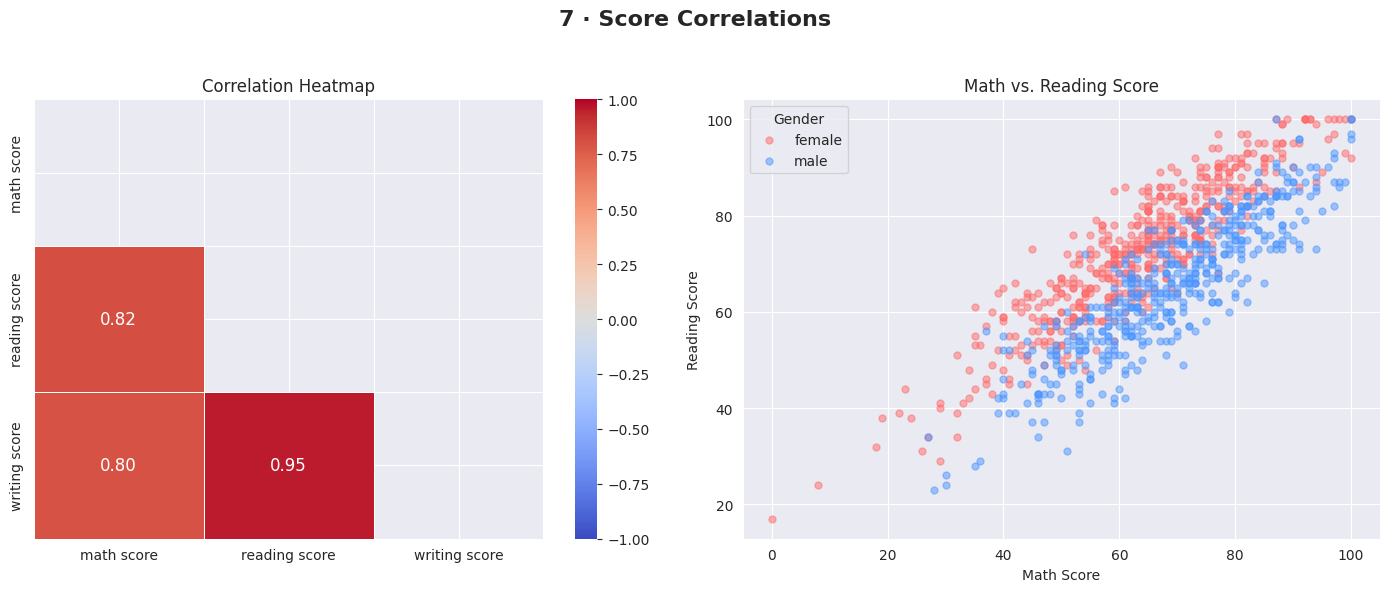


Correlation matrix:
               math score  reading score  writing score
math score          1.000          0.818          0.803
reading score       0.818          1.000          0.955
writing score       0.803          0.955          1.000


In [36]:
df[SCORE_COLS] = df[SCORE_COLS].apply(pd.to_numeric, errors="coerce")
df_clean = df.dropna(subset=SCORE_COLS)

PALETTE = {
    "female": "#FF6B6B",
    "male": "#4D96FF"
}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("7 · Score Correlations", fontsize=16, fontweight="bold")

corr = df_clean[SCORE_COLS].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    mask=mask,
    ax=axes[0],
    linewidths=0.5,
    vmin=-1,
    vmax=1,
    annot_kws={"size": 12}
)

axes[0].set_title("Correlation Heatmap")

for gender, grp in df_clean.groupby("gender"):
    axes[1].scatter(
        grp["math score"],
        grp["reading score"],
        alpha=0.5,
        s=25,
        label=gender,
        color=PALETTE.get(gender, "#333333")
    )

axes[1].set_xlabel("Math Score")
axes[1].set_ylabel("Reading Score")
axes[1].set_title("Math vs. Reading Score")
axes[1].legend(title="Gender")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("07_correlations.png", bbox_inches="tight")
plt.show()

print("\nCorrelation matrix:")
print(corr.round(3))

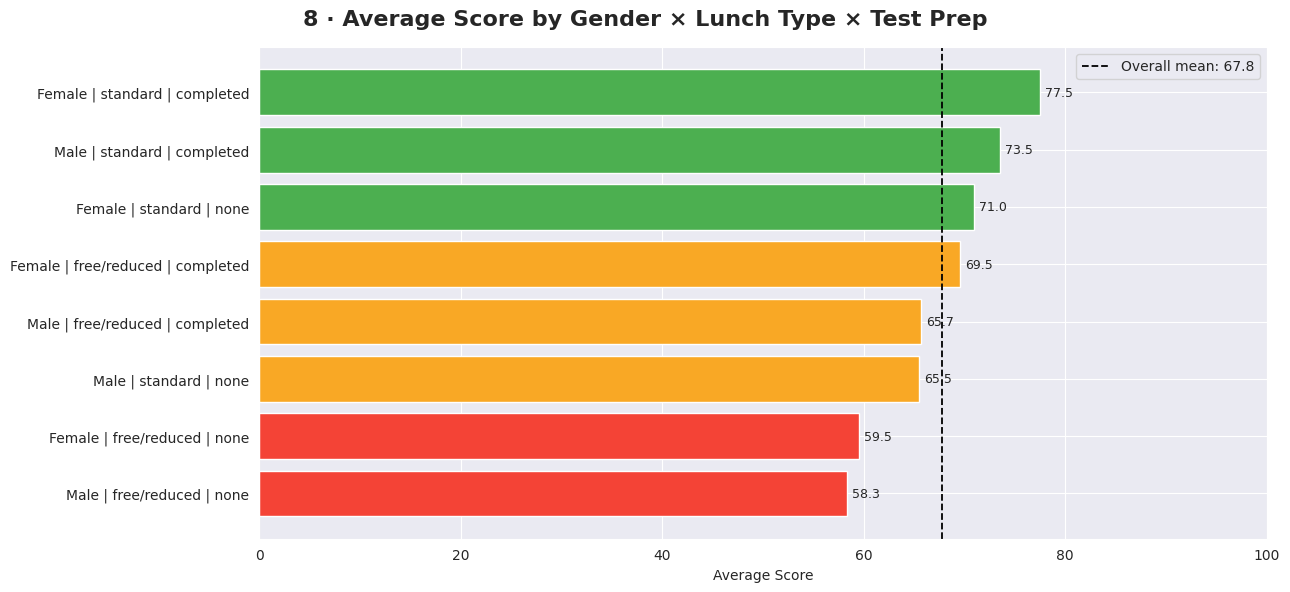


Top 3 best-performing combinations:
                        label  average score
Female | standard | completed      77.479912
  Male | standard | completed      73.513009
     Female | standard | none      70.961023

Bottom 3 combinations:
                       label  average score
  Male | free/reduced | none      58.323714
Female | free/reduced | none      59.501345
      Male | standard | none      65.485911


In [37]:
fig, ax = plt.subplots(figsize=(13, 6))
fig.suptitle("8 · Average Score by Gender × Lunch Type × Test Prep",
             fontsize=16, fontweight="bold")

combo = (df.groupby(["gender", "lunch", "test preparation course"])["average score"]
           .mean()
           .reset_index()
           .sort_values("average score", ascending=True))

combo["label"] = (combo["gender"].str.capitalize() + " | "
                  + combo["lunch"] + " | "
                  + combo["test preparation course"])

colors_map = combo["average score"].apply(
    lambda x: "#4CAF50" if x >= 70 else ("#F9A825" if x >= 60 else "#F44336")
)

bars = ax.barh(combo["label"], combo["average score"], color=colors_map)
ax.axvline(df["average score"].mean(), color="black", linestyle="--",
           linewidth=1.3, label=f"Overall mean: {df['average score'].mean():.1f}")
ax.set_xlabel("Average Score")
ax.set_xlim(0, 100)
for bar, val in zip(bars, combo["average score"]):
    ax.text(val + 0.5, bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}", va="center", fontsize=9)
ax.legend()

plt.tight_layout()
plt.savefig("08_combined_factors.png", bbox_inches="tight")
plt.show()

print("\nTop 3 best-performing combinations:")
print(combo.nlargest(3, "average score")[["label", "average score"]].to_string(index=False))
print("\nBottom 3 combinations:")
print(combo.nsmallest(3, "average score")[["label", "average score"]].to_string(index=False))

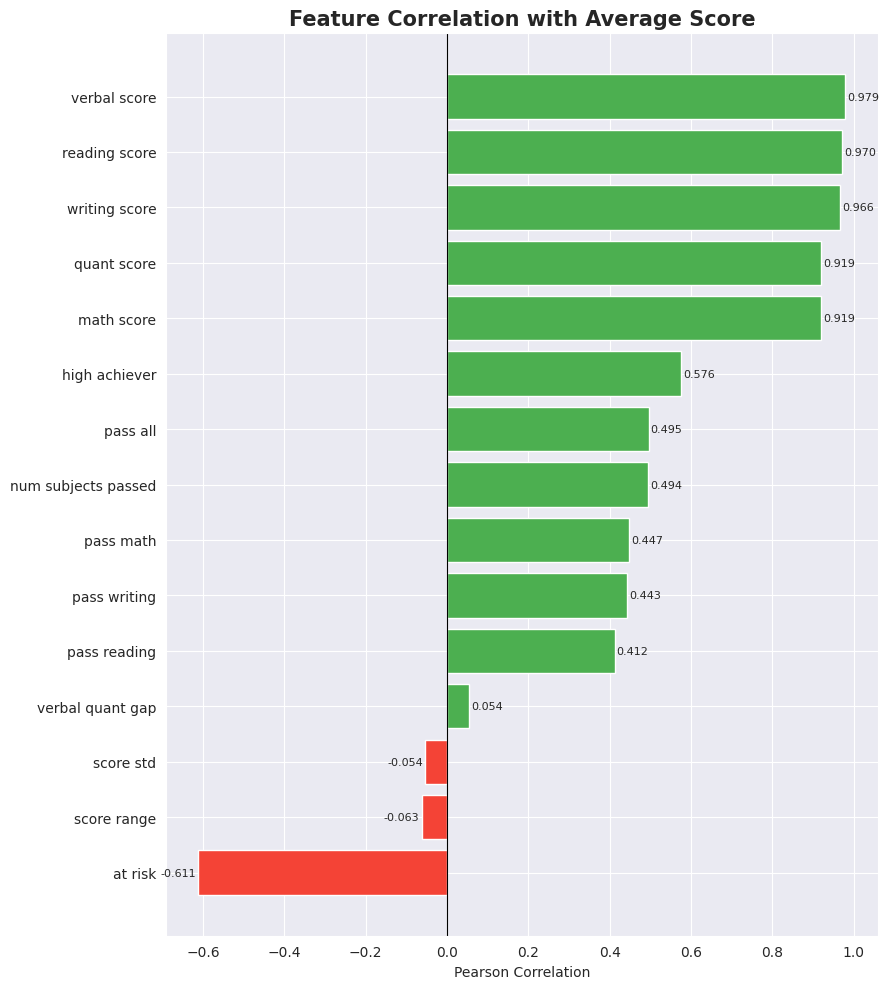

In [38]:
numeric_df = df.select_dtypes(include=[np.number])
corr_with_avg = (numeric_df.corr()["average score"]
                            .drop("average score")
                            .drop(["total score","min score","max score",
                                   "z_math","z_reading","z_writing",
                                   "scaled_math","scaled_reading","scaled_writing",
                                   "std_math","std_reading","std_writing",
                                   "log_math","log_reading","log_writing",
                                   "pct_math","pct_reading","pct_writing"], errors="ignore")
                            .sort_values())

fig, ax = plt.subplots(figsize=(9, 10))
colors  = ["#F44336" if v < 0 else "#4CAF50" for v in corr_with_avg]
ax.barh(corr_with_avg.index, corr_with_avg.values, color=colors, edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Feature Correlation with Average Score", fontsize=15, fontweight="bold")
ax.set_xlabel("Pearson Correlation")
for i, (val, name) in enumerate(zip(corr_with_avg.values, corr_with_avg.index)):
    ax.text(val + (0.005 if val >= 0 else -0.005), i,
            f"{val:.3f}", va="center", ha="left" if val >= 0 else "right", fontsize=8)
plt.tight_layout()
plt.savefig("fe_01_correlation_with_target.png", bbox_inches="tight")
plt.show()

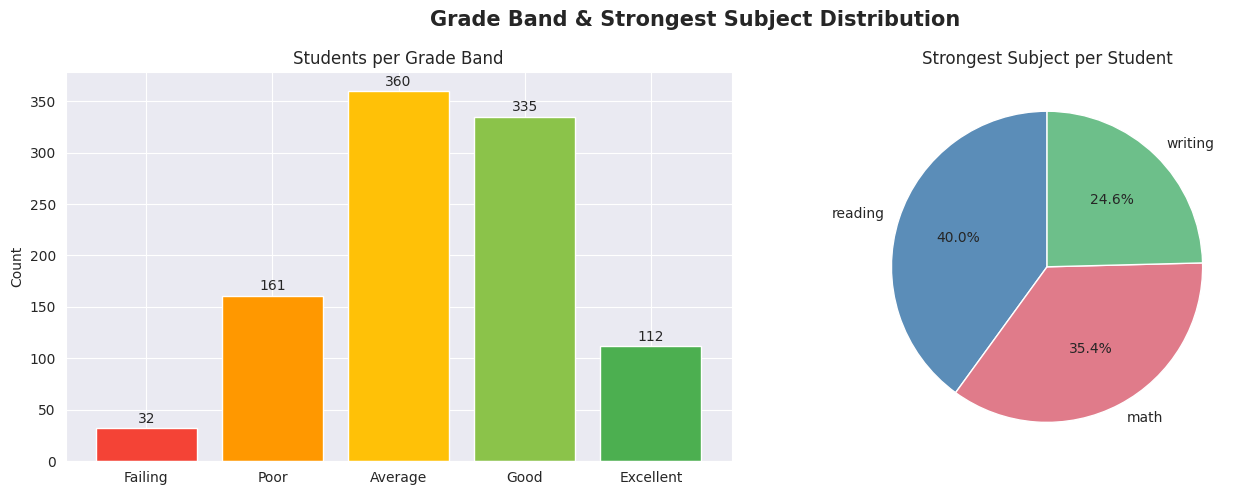

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Grade Band & Strongest Subject Distribution", fontsize=15, fontweight="bold")

band_counts = df["grade band"].value_counts().reindex(labels)
band_colors = ["#F44336","#FF9800","#FFC107","#8BC34A","#4CAF50"]
axes[0].bar(band_counts.index, band_counts.values, color=band_colors, edgecolor="white")
axes[0].set_title("Students per Grade Band")
axes[0].set_ylabel("Count")
for i, (idx, val) in enumerate(band_counts.items()):
    axes[0].text(i, val + 5, str(val), ha="center", fontsize=10)

subj_counts = df["strongest subject"].value_counts()
axes[1].pie(subj_counts, labels=subj_counts.index,
            autopct="%1.1f%%", colors=["#5B8DB8","#E07B8A","#6DBF8A"],
            startangle=90)
axes[1].set_title("Strongest Subject per Student")
plt.tight_layout()
plt.savefig("fe_02_grade_band_strongest_subject.png", bbox_inches="tight")
plt.show()

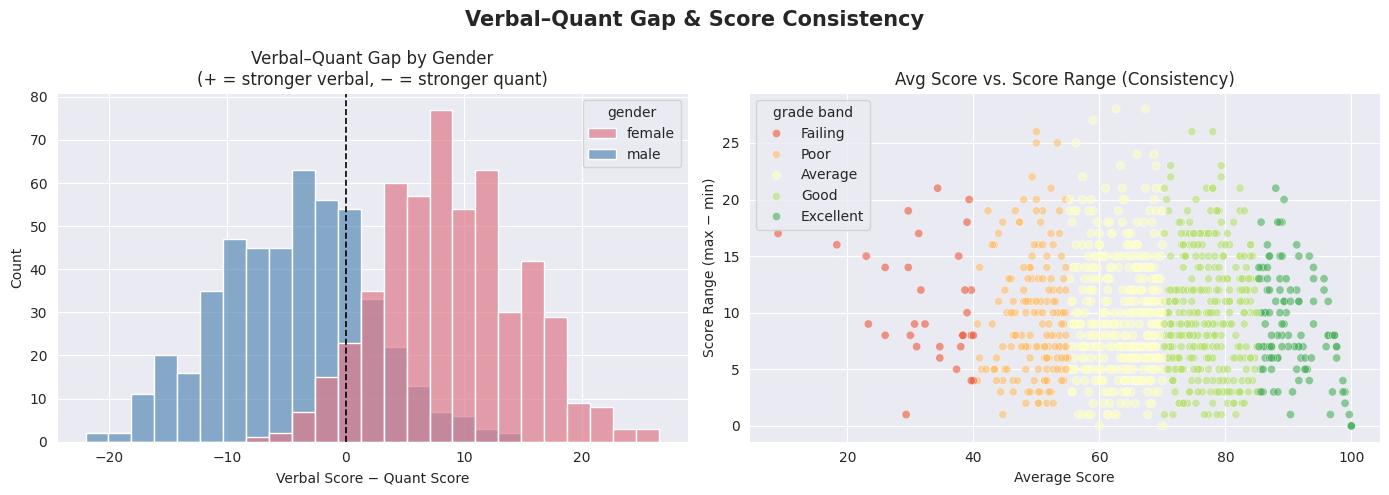

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Verbal–Quant Gap & Score Consistency", fontsize=15, fontweight="bold")

PALETTE = {"female": "#E07B8A", "male": "#5B8DB8"}
sns.histplot(data=df, x="verbal quant gap", hue="gender",
             palette=PALETTE, bins=25, alpha=0.7, ax=axes[0])
axes[0].axvline(0, color="black", linestyle="--", linewidth=1.2)
axes[0].set_title("Verbal–Quant Gap by Gender\n(+ = stronger verbal, − = stronger quant)")
axes[0].set_xlabel("Verbal Score − Quant Score")

sns.scatterplot(data=df, x="average score", y="score range",
                hue="grade band", palette="RdYlGn", alpha=0.6,
                hue_order=labels, ax=axes[1])
axes[1].set_title("Avg Score vs. Score Range (Consistency)")
axes[1].set_xlabel("Average Score")
axes[1].set_ylabel("Score Range (max − min)")

plt.tight_layout()
plt.savefig("fe_04_verbal_quant_consistency.png", bbox_inches="tight")
plt.show()